## Setup

In [1]:
from collections.abc import Callable

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.ndimage import rotate
from torch import nn
from torch.nn import functional as func
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from edl_losses.edl import EDLLoss, edl_inference
from edl_losses.fedl import FEDLLoss, fedl_inference
from edl_losses.gen import GENLoss, gen_inference

# Constants
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_EPOCHS = 30

torch.manual_seed(42)

# Data preparation
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256)

### Digit Rotation Plots

We want to plot the uncertainty/accuracy for possible rotation of the digit `1`.

In [2]:
def find_digit(dataset: torch.utils.data.Dataset, digit: int = 1) -> torch.Tensor:
    """Return the first occurrence of `digit` from the dataset as a (1,1,28,28) tensor.

    Arguments:
        dataset (torch.utils.data.Dataset): The dataset to search through.
        digit (int): The digit to find (0-9).

    Returns:
        torch.Tensor: A tensor of shape (1, 1, 28, 28) containing the first occurrence of the specified digit.

    """
    for img, label in dataset:
        if label == digit:
            return img.unsqueeze(0)  # (1, 1, 28, 28)

    msg = f"Digit {digit} not found in dataset."
    raise ValueError(msg)


def rotate_image(img_tensor: torch.Tensor, angle: float) -> torch.Tensor:
    """Rotate a (1, 1, 28, 28) tensor by `angle` degrees.

    Arguments:
        img_tensor (torch.Tensor): A tensor of shape (1, 1, 28, 28) representing the image to rotate.
        angle (float): The angle in degrees to rotate the image. Positive values rotate counter-clockwise.

    Returns:
        torch.Tensor: A tensor of shape (1, 1, 28, 28) containing the rotated image.

    """
    img_np = img_tensor.squeeze().numpy()  # (28, 28)
    rotated = rotate(img_np, angle, reshape=False)  # same shape, fills with 0

    return torch.tensor(rotated, dtype=torch.float32).unsqueeze(0).unsqueeze(0)


digit_img = find_digit(train_data, digit=1)
n_steps = 37  # ~5° increments like the paper
angles = np.linspace(0, 180, n_steps)


def plot_rotation_analysis(
    model: nn.Module,
    inference_fn: Callable,
    true_class: int = 1,
) -> None:
    """Plot the rotation analysis results.

    Arguments:
        model (nn.Module): The trained model to analyze.
        inference_fn (Callable): The inference function to use (e.g., edl_inference).
        true_class (int): The true class index to plot the probability for (default is 1 for digit '1').

    """
    all_probs = np.zeros((n_steps, 10))
    all_uncertainty = np.zeros(n_steps)

    for i, angle in enumerate(angles):
        rotated = rotate_image(digit_img, angle)
        model_results = model(rotated.to(DEVICE))
        if not isinstance(model_results, tuple):
            model_results = (model_results,)
        _, uncertainty, class_probs = inference_fn(*model_results)
        all_probs[i] = class_probs.detach().squeeze().cpu().numpy()
        all_uncertainty[i] = uncertainty.detach().cpu().item()

    p_correct = all_probs[:, true_class]

    plt.figure(figsize=(8, 5))

    plt.plot(angles, p_correct, label="P(correct)", color="black", marker="s", markevery=4, linewidth=1.5)
    plt.plot(
        angles,
        all_uncertainty,
        label="uncertainty",
        color="green",
        marker="x",
        markevery=4,
        linewidth=1.5,
        linestyle="--",
    )

    plt.title("Rotation Analysis of Digit '1'")
    plt.xlabel("Rotation Angle")
    plt.ylabel("Probability / Uncertainty")
    plt.xlim(0, 180)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### Evaluation function

In [3]:
def evaluate_model(model: nn.Module, inference_fn: Callable) -> None:
    """Evaluate the model on the test set and print accuracy and uncertainty statistics.

    Arguments:
        model (nn.Module): The trained model to evaluate.
        inference_fn (Callable): The inference function to use (e.g., edl_inference).

    """
    model.eval()

    correct = total = 0
    mean_uncertainty_correct = mean_uncertainty_wrong = 0
    n_correct = n_wrong = 0

    with torch.no_grad():
        for x, y in test_loader:
            model_results = model(x.to(DEVICE))
            if not isinstance(model_results, tuple):
                model_results = (model_results,)
            pred, uncertainty, _ = inference_fn(*model_results)

            mask_correct = pred == y.to(DEVICE)
            mask_wrong = ~mask_correct

            correct += mask_correct.sum().item()
            total += y.to(DEVICE).size(0)
            mean_uncertainty_correct += uncertainty[mask_correct].sum().item()
            mean_uncertainty_wrong += uncertainty[mask_wrong].sum().item()
            n_correct += mask_correct.sum().item()
            n_wrong += mask_wrong.sum().item()

    print(f"\nTest accuracy: {correct / total:.4f}")
    print(f"Mean uncertainty — correct: {mean_uncertainty_correct / max(n_correct, 1):.4f}")
    print(f"Mean uncertainty — wrong: {mean_uncertainty_wrong / max(n_wrong, 1):.4f}")

### LeNet Model

We will evaluate all EDL loss functions using the same LeNet architecture

In [4]:
class LeNet(nn.Module):
    """Standard LeNet-5 for MNIST. Returns flat features before classifier."""

    def __init__(self) -> None:
        """Initialize the LeNet architecture."""
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 20, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(20, 50, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(nn.Linear(800, 500), nn.ReLU())

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through the LeNet architecture.

        Arguments:
            x: Input tensor of shape (batch_size, 1, 28, 28) representing grayscale images.

        Returns:
            Tensor of shape (batch_size, 500) representing the features before the classifier.

        """
        return self.fc(self.features(x).flatten(1))

## EDL

In [5]:
class EDLModel(nn.Module):
    """EDL classifier with LeNet backbone. Outputs raw logits for evidence (no softmax)."""

    def __init__(self, num_classes: int = 10) -> None:
        """Initialize the EDL model architecture."""
        super().__init__()
        self.backbone = LeNet()
        self.classifier = nn.Linear(500, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through the EDL model.

        Arguments:
            x: Input tensor of shape (batch_size, 1, 28, 28) representing grayscale images.

        Returns:
            Tensor of shape (batch_size, num_classes) representing raw logits for evidence.

        """
        return self.classifier(self.backbone(x))  # raw logits, NO softmax

In [ ]:
model = EDLModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = EDLLoss()

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        optimizer.zero_grad()
        loss = loss_fn(model(x.to(DEVICE)), y.to(DEVICE), epoch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch}/{NUM_EPOCHS} loss={total_loss / len(train_loader):.4f}")

Epoch 1/30 loss=0.5211
Epoch 2/30 loss=0.3957
Epoch 3/30 loss=0.3778
Epoch 4/30 loss=0.3629
Epoch 5/30 loss=0.3599
Epoch 6/30 loss=0.3534
Epoch 7/30 loss=0.3503
Epoch 8/30 loss=0.3472
Epoch 9/30 loss=0.3452
Epoch 10/30 loss=0.3417
Epoch 11/30 loss=0.3402
Epoch 12/30 loss=0.3371
Epoch 13/30 loss=0.3316
Epoch 14/30 loss=0.3298
Epoch 15/30 loss=0.3260
Epoch 16/30 loss=0.3271
Epoch 17/30 loss=0.3239
Epoch 18/30 loss=0.3201
Epoch 19/30 loss=0.3200
Epoch 20/30 loss=0.3217
Epoch 21/30 loss=0.3232
Epoch 22/30 loss=0.3175
Epoch 23/30 loss=0.3165
Epoch 24/30 loss=0.3177
Epoch 25/30 loss=0.3149
Epoch 26/30 loss=0.3130
Epoch 27/30 loss=0.3145
Epoch 28/30 loss=0.3148
Epoch 29/30 loss=0.3141
Epoch 30/30 loss=0.3112



Test accuracy: 0.6984
Mean uncertainty — correct: 0.0605
Mean uncertainty — wrong: 0.9919


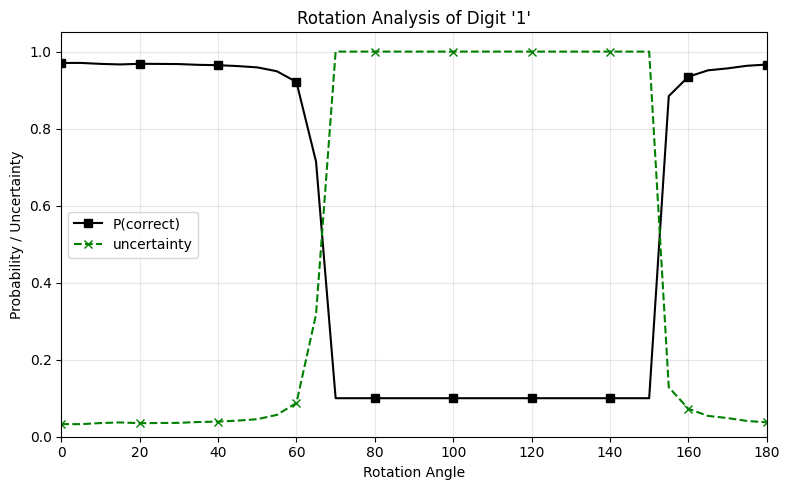

In [7]:
evaluate_model(model, edl_inference)
plot_rotation_analysis(model, edl_inference)

## GEN

In [8]:
class GENModel(nn.Module):
    """Same classifier as EDL. OOD samples are generated externally during training."""

    def __init__(self, num_classes: int = 10) -> None:
        """Initialize the GEN model architecture."""
        super().__init__()
        self.backbone = LeNet()
        self.classifier = nn.Linear(500, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through the GEN model.

        Arguments:
            x: Input tensor of shape (batch_size, 1, 28, 28) representing grayscale images.

        Returns:
            Tensor of shape (batch_size, num_classes) representing raw logits for classification.

        """
        return self.classifier(self.backbone(x))

In [ ]:
def _make_ood_samples(x: torch.Tensor) -> torch.Tensor:
    """Add Gaussian noise to push samples off-distribution.

    In production this would be the VAE+GAN generator from the paper.

    Arguments:
        x: Input tensor of shape (batch_size, 1, 28, 28) representing grayscale images.

    Returns:
        Tensor of the same shape as x, but with added noise to simulate OOD samples.

    """
    return torch.clamp(x + 0.3 * torch.randn_like(x), 0, 1)


model = GENModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = GENLoss()

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x_ood = _make_ood_samples(x.to(DEVICE))
        optimizer.zero_grad()
        loss = loss_fn(model(x.to(DEVICE)), model(x_ood), y.to(DEVICE))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}/{NUM_EPOCHS} loss={total_loss / len(train_loader):.4f}")

Epoch 1/30 loss=0.4683
Epoch 2/30 loss=0.1300
Epoch 3/30 loss=0.0882
Epoch 4/30 loss=0.0698
Epoch 5/30 loss=0.0572
Epoch 6/30 loss=0.0458
Epoch 7/30 loss=0.0376
Epoch 8/30 loss=0.0291
Epoch 9/30 loss=0.0244
Epoch 10/30 loss=0.0225
Epoch 11/30 loss=0.0171
Epoch 12/30 loss=0.0188
Epoch 13/30 loss=0.0125
Epoch 14/30 loss=0.0108
Epoch 15/30 loss=0.0119
Epoch 16/30 loss=0.0106
Epoch 17/30 loss=0.0076
Epoch 18/30 loss=0.0141
Epoch 19/30 loss=0.0101
Epoch 20/30 loss=0.0069
Epoch 21/30 loss=0.0069
Epoch 22/30 loss=0.0101
Epoch 23/30 loss=0.0037
Epoch 24/30 loss=0.0022
Epoch 25/30 loss=0.0138
Epoch 26/30 loss=0.0057
Epoch 27/30 loss=0.0048
Epoch 28/30 loss=0.0011
Epoch 29/30 loss=0.0003
Epoch 30/30 loss=0.0001



Test accuracy: 0.9937
Mean uncertainty — correct: 0.0029
Mean uncertainty — wrong: 0.2086


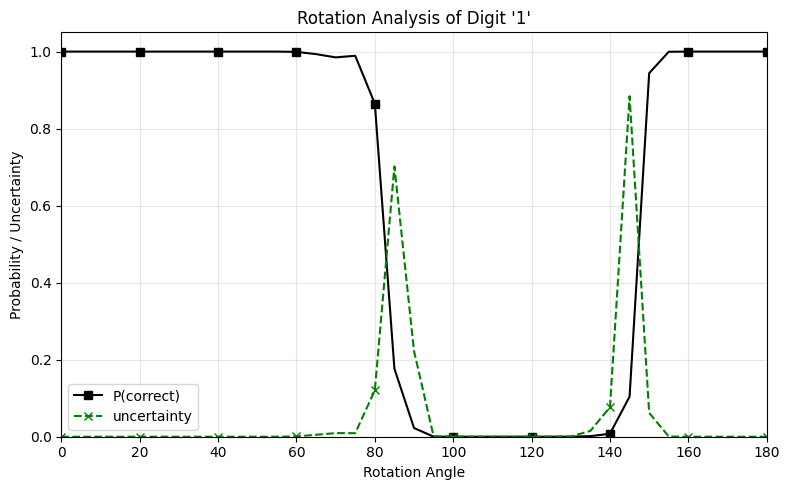

In [10]:
evaluate_model(model, gen_inference)
plot_rotation_analysis(model, gen_inference)

## F-EDL

In [11]:
class FEDLModel(nn.Module):
    """F-EDL classifier with LeNet backbone. Outputs separate heads for alpha, p, and tau."""

    def __init__(self, num_classes: int = 10, mlp_hidden: int = 64) -> None:
        """Initialize the F-EDL model architecture."""
        super().__init__()
        self.backbone = LeNet()

        # Three separate heads
        self.head_alpha = nn.Linear(500, num_classes)  # evidence
        self.head_p = nn.Linear(500, num_classes)  # allocation probs
        self.head_tau = nn.Sequential(  # dispersion
            nn.Linear(500, mlp_hidden),
            nn.ReLU(),
            nn.Linear(mlp_hidden, 1),
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Forward pass through the F-EDL model.

        Arguments:
            x: Input tensor of shape (batch_size, 1, 28, 28) representing grayscale images.

        Returns:
            alpha: Tensor of shape (batch_size, num_classes) representing evidence for each class.
            p: Tensor of shape (batch_size, num_classes) representing allocation probabilities.
            tau: Tensor of shape (batch_size,) representing dispersion.

        """
        z = self.backbone(x)
        alpha = torch.exp(self.head_alpha(z))
        p = torch.softmax(self.head_p(z), dim=-1)
        tau = func.softplus(self.head_tau(z)).squeeze(-1)
        return alpha, p, tau

In [ ]:
model = FEDLModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = FEDLLoss()

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        optimizer.zero_grad()
        alpha, p, tau = model(x.to(DEVICE))
        alpha = torch.clamp(alpha, 1e-6, 1e4)
        tau = torch.clamp(tau, 1e-6, 1e4)
        loss = loss_fn(alpha, p, tau, y.to(DEVICE))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}/{NUM_EPOCHS} loss={total_loss / len(train_loader):.4f}")

Epoch 1/30 loss=0.2748
Epoch 2/30 loss=0.0675
Epoch 3/30 loss=0.0460
Epoch 4/30 loss=0.0353
Epoch 5/30 loss=0.0280
Epoch 6/30 loss=0.0240
Epoch 7/30 loss=0.0209
Epoch 8/30 loss=0.0184
Epoch 9/30 loss=0.0136
Epoch 10/30 loss=0.0135
Epoch 11/30 loss=0.0117
Epoch 12/30 loss=0.0084
Epoch 13/30 loss=0.0075
Epoch 14/30 loss=0.0086
Epoch 15/30 loss=0.0100
Epoch 16/30 loss=0.0076
Epoch 17/30 loss=0.0056
Epoch 18/30 loss=0.0060
Epoch 19/30 loss=0.0060
Epoch 20/30 loss=0.0074
Epoch 21/30 loss=0.0078
Epoch 22/30 loss=0.0064
Epoch 23/30 loss=0.0040
Epoch 24/30 loss=0.0064
Epoch 25/30 loss=0.0046
Epoch 26/30 loss=0.0043
Epoch 27/30 loss=0.0034
Epoch 28/30 loss=0.0044
Epoch 29/30 loss=0.0043
Epoch 30/30 loss=0.0039



Test accuracy: 0.9930
Mean uncertainty — correct: 0.0029
Mean uncertainty — wrong: 0.2384


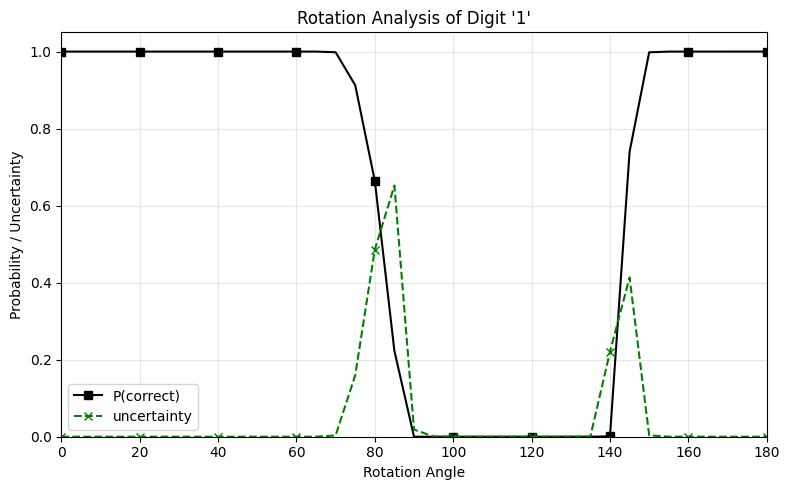

In [13]:
evaluate_model(model, fedl_inference)
plot_rotation_analysis(model, fedl_inference)